In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Contours



Edges of objects in the image

- used to detect objects, shape, and measure their size
- work on binary images because it provides sharp edges

findContours(): 

find the edges, take 3 arguments

- Source Image: image from which we want to find the contours
- Contour Retrieval Mode: This determines how contours are retrieved
 - - 1.	Retrieve External: output only the external contours
 - - 2.	Retrieve List: output all contours without any hierarchical relationship
 - - 3.	Retrieve Tree: output all contours with hierarchical relationship


Contour Approximation Method: 

This decides how much detail to keep when storing the contours
- - 1.	CHAIN_APPROX_NONE: all points are stored, no compression
- - 2.	CHAIN_APPROX_SIMPLE: store some points in straight objects like rectangle need 4 points
- - 3.	CHAIN_APPROX_TCB89_L1
- - 4.	CHAIN_APPROX_TCB89_COS


Output

The function gives us three outputs:

- Image: The image with contours found in it
- Contours: A list of contours. Each contour is made up of the (x, y) coordinates that outline a shape in the image
- Hierarchy: This gives extra information about the contours like which ones are inside others

drawContours()

Draw the contours on original image to visualize the image

Number of contours found: 11


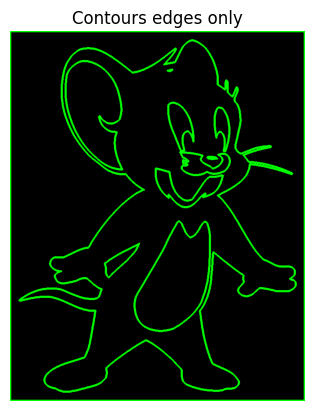

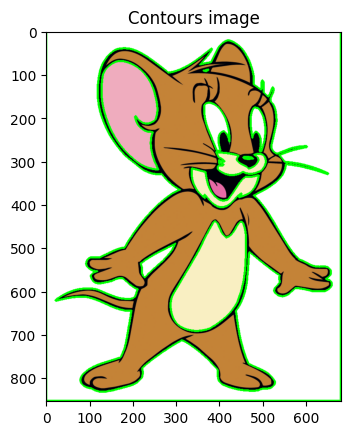

In [3]:
#contours
img_jerry=cv.imread('H:/OpenCV-Mastery-Roadmap/images/jerry.png')
gray_for_contours = cv.cvtColor(img_jerry, cv.COLOR_BGR2GRAY)
binary_for_contours = cv.threshold(gray_for_contours, 0, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)

#cv.findContours(image, mode, method)
contours, hierarchy = cv.findContours(binary_for_contours[1], cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
print(f'Number of contours found: {len(contours)}')

# draw contours on the original image
# cv.drawContours(image, contours, contourIdx, color, thickness)
jerry_with_contours=cv.drawContours(img_jerry, contours, -1, (0,255,0), 3)

# show the image with contours in matplotlib
# show only contour edges on a black background
edges_only = np.zeros_like(img_jerry) # create a black image with the same shape as the original
edges_only = cv.drawContours(edges_only, contours, -1, (0,255,0), 3)
plt.imshow(cv.cvtColor(edges_only, cv.COLOR_BGR2RGB))
plt.title('Contours edges only')
plt.axis('off')
plt.show()

plt.imshow(cv.cvtColor(jerry_with_contours, cv.COLOR_BGR2RGB))
plt.title('Contours image')
plt.show()



# cv.imshow('Contours', jerry_with_contours)
# cv.imshow('Gray', gray_for_contours)
# cv.imshow('Binary', binary_for_contours[1])
# cv.waitKey(0)
# cv.destroyAllWindows()


# Histograms

### Gray Histogram

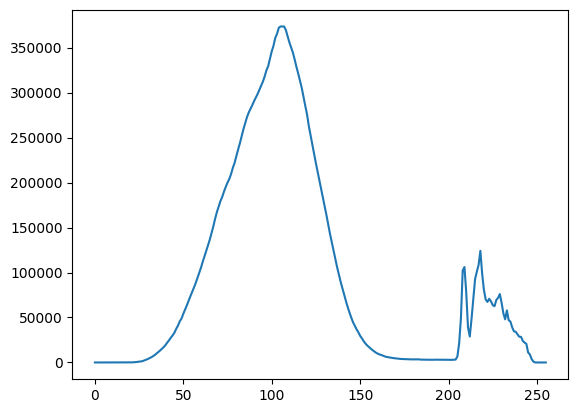

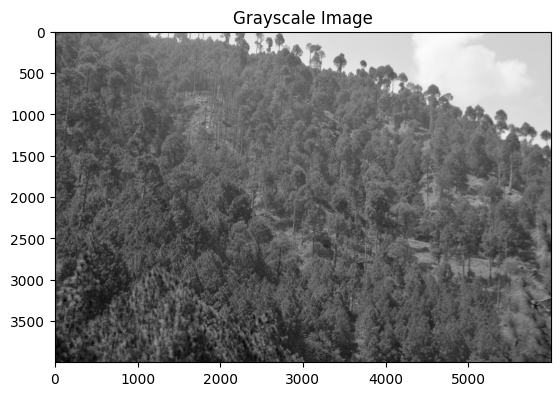

In [6]:
# calculate histogram 
forest = cv.imread('../images/forest.jpg')
gray_forest = cv.cvtColor(forest, cv.COLOR_BGR2GRAY)

#        cv.calcHist(images, channels, mask, histSize, ranges)
hist = cv.calcHist([gray_forest], [0], None, [256], [0, 256])
plt.plot(hist)
plt.show()  

plt.imshow(gray_forest, cmap='gray')
plt.title('Grayscale Image')
plt.show()

#### Equalize the Histogram

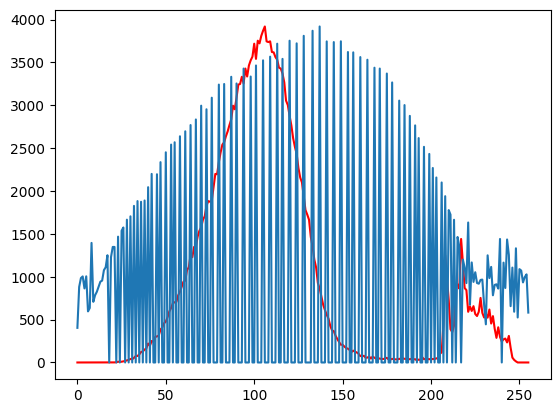

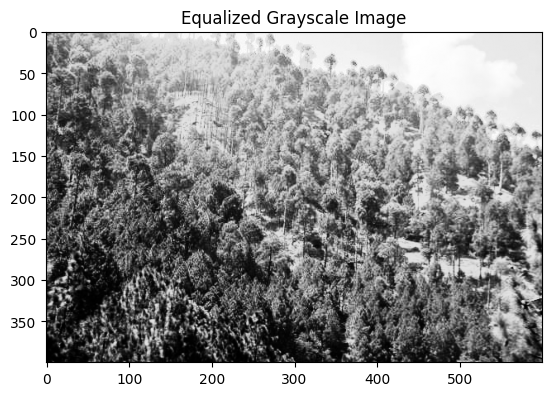

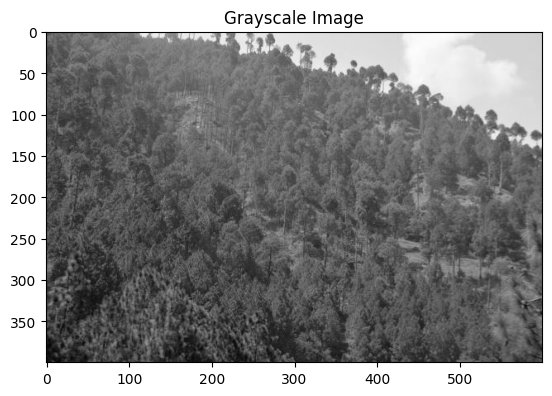

In [12]:
# calculate histogram 
forest = cv.imread('../images/forest.jpg')
gray_forest = cv.cvtColor(forest, cv.COLOR_BGR2GRAY)

#        cv.calcHist(images, channels, mask, histSize, ranges)
hist_gray = cv.calcHist([gray_forest], [0], None, [256], [0, 256])
plt.plot(hist_gray, color='red')
equalize_hist_gray = cv.equalizeHist(gray_forest)
hist_gray = cv.calcHist([equalize_hist_gray], [0], None, [256], [0, 256])
plt.plot(hist_gray)
plt.show()  
    
plt.imshow(equalize_hist_gray, cmap='gray')
plt.title('Equalized Grayscale Image')
plt.show()
plt.imshow(gray_forest, cmap='gray')
plt.title('Grayscale Image')
plt.show()

### Colored Histogram

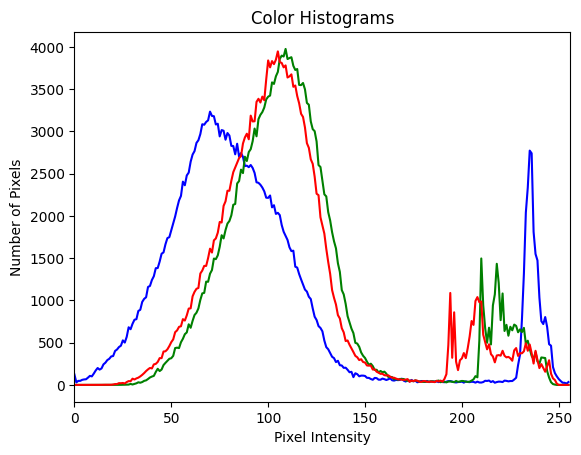

In [ ]:
# color histogram
forest = cv.imread('../images/forest.jpg')
b,g,r= cv.split(forest)

# calculate histogram for each channel
hist_b = cv.calcHist([b], [0], None, [256], [0, 256])
hist_g = cv.calcHist([g], [0], None, [256], [0, 256])
hist_r = cv.calcHist([r], [0], None, [256], [0, 256])
# plot the histograms
plt.plot(hist_b, color='blue')
plt.plot(hist_g, color='green')
plt.plot(hist_r, color='red')
plt.title('Color Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Number of Pixels')
plt.xlim([0, 256])
plt.show()

